In [9]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [20]:
def load_simulation_results(directory_path):
    """
    Loads all .csv files from a directory into a single pandas DataFrame.
    Adds a 'source_file' column to identify the origin of each data point.
    """
    path = Path(directory_path)
    
    # Use glob to find all CSV files
    csv_files = list(path.glob("*.csv"))
    
    if not csv_files:
        print(f"Warning: No .csv files found in {directory_path}")
        return pd.DataFrame()
    
    # Load each file and add the source identifier
    dfs = []
    for file in csv_files:
        df = pd.read_csv(file)
        # Identify source file (removes the .csv extension for cleaner labeling)
        df['source_file'] = file.stem 
        dfs.append(df)
    
    # Concatenate all into one big dataframe
    combined_df = pd.concat(dfs, ignore_index=True)
    
    # Optional: Convert tick to numeric if it isn't already
    combined_df['tick'] = pd.to_numeric(combined_df['tick'])
    
    print(f"Successfully loaded {len(csv_files)} files with a total of {len(combined_df)} rows.")
    return combined_df

In [21]:
# Example usage (assuming you are in your 'analysis/' folder)

df = load_simulation_results("data/_OTHER")

Successfully loaded 1 files with a total of 5000 rows.


In [22]:
df.head(8)

,tick,topic_id,popularity,gini_index,polarized,agents,ideology_weight,source_file
0,30,t_0_g_0,0.220,0.036,True,500,1,default long
1,30,t_1_g_0,0.198,0.036,True,500,1,default long
2,30,t_2_g_0,0.196,0.036,True,500,1,default long
3,30,t_3_g_0,0.186,0.036,True,500,1,default long
4,30,t_4_g_0,0.200,0.036,True,500,1,default long
5,60,t_0_g_0,0.220,0.036,True,500,1,default long
6,60,t_1_g_0,0.198,0.036,True,500,1,default long
7,60,t_2_g_0,0.196,0.036,True,500,1,default long


In [38]:
def plot_single_run_popularity(df, source_filename):
    """
    Plots the popularity of topics over time for a specific simulation run.
    """
    # 1. Filter for the specific run
    run_df = df[df['source_file'] == source_filename].copy()
    
    if run_df.empty:
        print(f"No data found for source: {source_filename}")
        return

    # 2. Extract base topic (e.g., 't_0' from 't_0_g_0') 
    # This ensures lines are continuous even after a topic 'rebirth'
    run_df['topic_idx'] = run_df['topic_id'].apply(lambda x: "_".join(x.split("_")[:2]))

    # 3. Create the plot
    plt.figure(figsize=(10, 6))
    
    # Get unique topics (supports up to 9 as requested)
    unique_topics = sorted(run_df['topic_idx'].unique())
    
    for topic in unique_topics:
        topic_data = run_df[run_df['topic_idx'] == topic].sort_values('tick')
        plt.plot(topic_data['tick'], topic_data['popularity'], label=topic, linewidth=1.5)

    # 4. Formatting
    plt.title("Topic Popularity Over Time", fontsize=14)
    plt.xlabel("Ticks", fontsize=12)
    plt.ylabel("Popularity (Network News Value)", fontsize=12)
    
    # Place legend outside the plot for clarity with many topics
    plt.legend(title="Topics", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    plt.savefig(f"default long topics.png")
    
    plt.show()


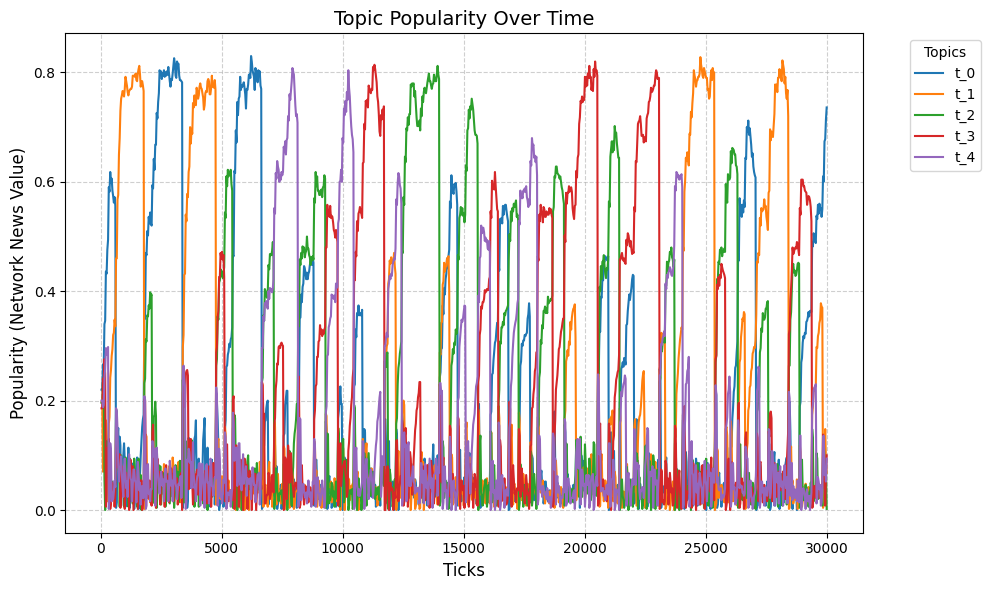

In [39]:
# Usage:
plot_single_run_popularity(df, "default long")

In [40]:
def plot_gini_over_time(df, source_filename):
    """
    Plots the Gini index over time for a specific simulation run to visualize
    how attention inequality evolves.
    """
    # 1. Filter for the specific run
    run_df = df[df['source_file'] == source_filename].copy()
    
    if run_df.empty:
        print(f"No data found for source: {source_filename}")
        return

    # 2. Deduplicate: The Gini index is a system-wide metric repeated for each topic.
    # We only need one value per tick.
    gini_data = run_df.groupby('tick')['gini_index'].first().reset_index().sort_values('tick')

    # 3. Create the plot
    plt.figure(figsize=(10, 5))
    plt.plot(gini_data['tick'], gini_data['gini_index'], 
             color='black', 
             linewidth=2, 
             label='Gini Index')

    # 4. Formatting
    plt.title("Attention Inequality (Gini Index) Over Time", fontsize=14)
    plt.xlabel("Ticks", fontsize=12)
    plt.ylabel("Gini Index (0=Equality, 1=Monopoly)", fontsize=12)
    
    # Ensure the y-axis is always 0-1 for consistent visual comparison
    plt.ylim(-0.02, 1.02)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(f"default long gini.png")
    plt.show()

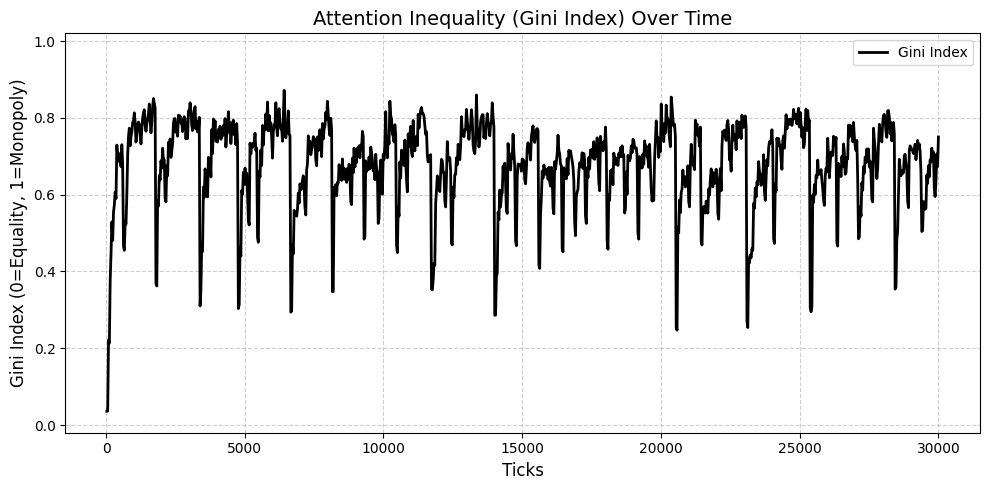

In [41]:
plot_gini_over_time(df, "default long")

In [ ]:
def plot_gini_boxplot(df):
    """
    Creates a boxplot of the Gini index distribution across the entire dataset.
    Deduplicates Gini values to ensure each tick/run is only counted once.
    """
    # 1. Deduplicate: The Gini index is a system-wide metric repeated for each topic.
    # We take the first Gini value per unique (run, tick) combination.
    gini_series = df.groupby(['source_file', 'tick'])['gini_index'].first()

    # 2. Create the plot
    plt.figure(figsize=(8, 6))
    
    # Use patch_artist=True to allow filling the box with color
    result = plt.boxplot(gini_series, 
                         patch_artist=True, 
                         boxprops=dict(facecolor='lightblue', color='blue'),
                         medianprops=dict(color='red', linewidth=2),
                         whiskerprops=dict(color='blue'),
                         capprops=dict(color='blue'))

    # 3. Formatting
    plt.title("Distribution of Attention Inequality (Gini Index)/nAll Simulation Runs", fontsize=14)
    plt.ylabel("Gini Index (0 = Perfect Equality, 1 = Monopoly)", fontsize=12)
    plt.xticks([1], ["All Runs"]) # Label for the x-axis tick
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig('gini_distribution.svg')
    
    plt.show()

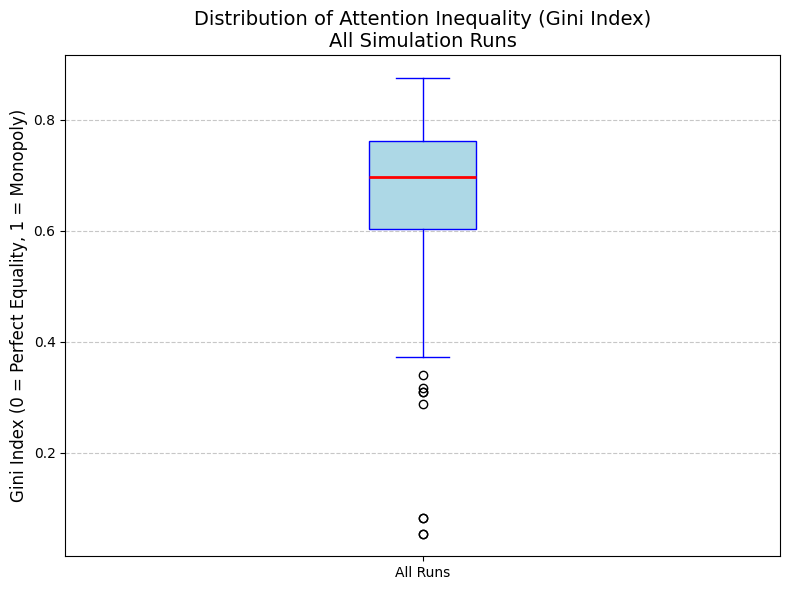

In [19]:
plot_gini_boxplot(df)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def plot_comparative_gini_violin(df):
    """
    Creates a split violin plot to compare attention inequality (Gini index) 
    across different ideology weights and societal distributions.
    """
    # 1. Deduplicate: We only want one system-wide Gini value per tick per run.
    # Grouping by all the parameter columns ensures we keep the configuration data attached.
    gini_df = df.groupby(['source_file', 'tick', 'polarized', 'ideology_weight'])['gini_index'].first().reset_index()

    # 2. Clean up labels for a professional plot
    gini_df['Society Type'] = gini_df['polarized'].apply(
        lambda x: 'Polarized (Bimodal)' if str(x).lower() == 'true' else 'Homogeneous (Normal)'
    )
    
    # 3. Create the Seaborn Violin Plot
    plt.figure(figsize=(10, 6))
    
    # 'split=True' puts Normal on the left and Polarized on the right of the same "violin"
    sns.violinplot(
        data=gini_df,
        x='ideology_weight',
        y='gini_index',
        hue='Society Type',
        split=True, 
        inner='quartile', # Draws dashed lines for the 25th, 50th, and 75th percentiles
        palette='Set2',
        linewidth=1.2
    )

    # 4. Formatting
    plt.title("Impact of Ideology and Polarization on Attention Inequality/n(Distribution of Gini Index)", fontsize=14)
    plt.xlabel("Importance of Ideology (Weight)", fontsize=12)
    plt.ylabel("Gini Index (0 = Equality, 1 = Monopoly)", fontsize=12)
    
    plt.ylim(-0.05, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(title="Societal Distribution", loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    
    # Save as a high-quality vector graphic for your LaTeX report
    plt.savefig('comparative_gini_violin.png', bbox_inches='tight')
    plt.show()

In [44]:
def load_all_experiments(parent_directory):
    path = Path(parent_directory)
    # rglob searches through all subfolders automatically
    dfs = [pd.read_csv(f).assign(source_file=f.stem) for f in path.rglob("*.csv")]
    
    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df['tick'] = pd.to_numeric(combined_df['tick'])
    return combined_df

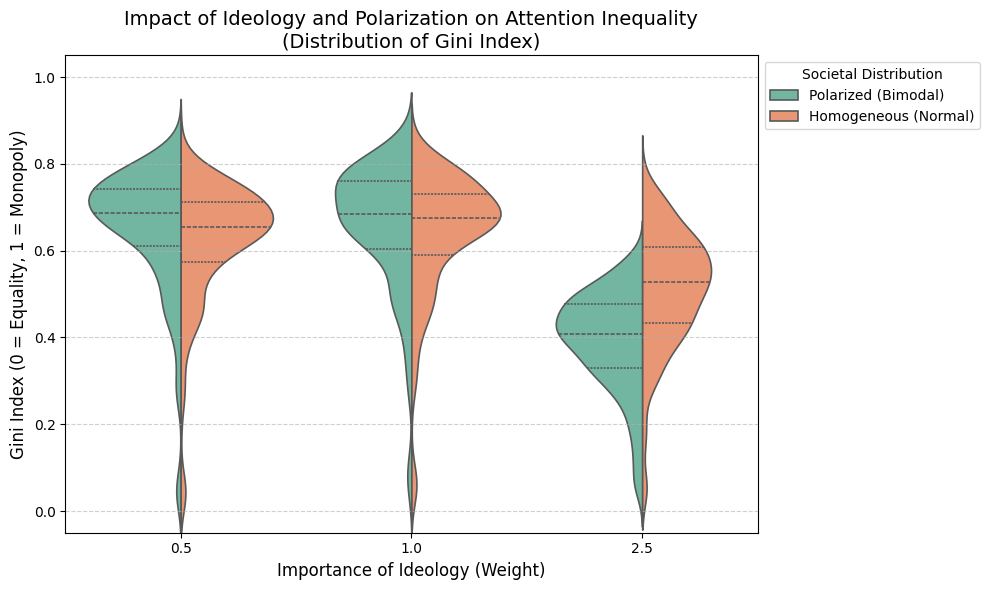

In [45]:
# Usage:
df_all = load_all_experiments("C:/Users/leond/Desktop/exp")
plot_comparative_gini_violin(df_all)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_comparative_gini_timeseries(df):
    """
    Creates a side-by-side time series plot of the Mean Gini index.
    Automatically handles multiple runs by plotting confidence intervals.
    """
    # 1. Deduplicate: Get one system-wide Gini value per tick per run.
    gini_df = df.groupby(['source_file', 'tick', 'polarized', 'ideology_weight'])['gini_index'].first().reset_index()

    # 2. Clean up labels for a professional layout
    gini_df['Society Type'] = gini_df['polarized'].apply(
        lambda x: 'Polarized (Bimodal)' if str(x).lower() == 'true' else 'Homogeneous (Normal)'
    )
    
    # Treat ideology weight as a categorical variable for distinct line colors
    gini_df['Ideology Weight'] = gini_df['ideology_weight'].astype(str)

    # 3. Create the Seaborn Relational Plot (FacetGrid)
    # 'col' creates side-by-side plots, 'hue' draws different colored lines
    g = sns.relplot(
        data=gini_df,
        kind="line",
        x="tick",
        y="gini_index",
        hue="Ideology Weight",
        col="Society Type",
        palette="Set1",      # High contrast color palette
        height=5,            # Height of each subplot
        aspect=1.2,          # Width-to-height ratio
        linewidth=2
    )

    # 4. Formatting and aesthetics
    g.set_axis_labels("Ticks", "Mean Gini Index (Inequality)", fontsize=12)
    g.set_titles(col_template="{col_name}", size=13, weight='bold') 
    
    # Apply strict 0-1 limits and grid lines to all subplots
    for ax in g.axes.flat:
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle='--', alpha=0.6)

    # Add an overarching title
    plt.suptitle("Evolution of Attention Inequality Over Time\nComparing Societal Distributions and Ideology Weights", 
                 y=1.08, fontsize=15)
    
    # Save as vector graphic for LaTeX
    plt.savefig('comparative_gini_timeseries.svg', bbox_inches='tight')
    plt.show()

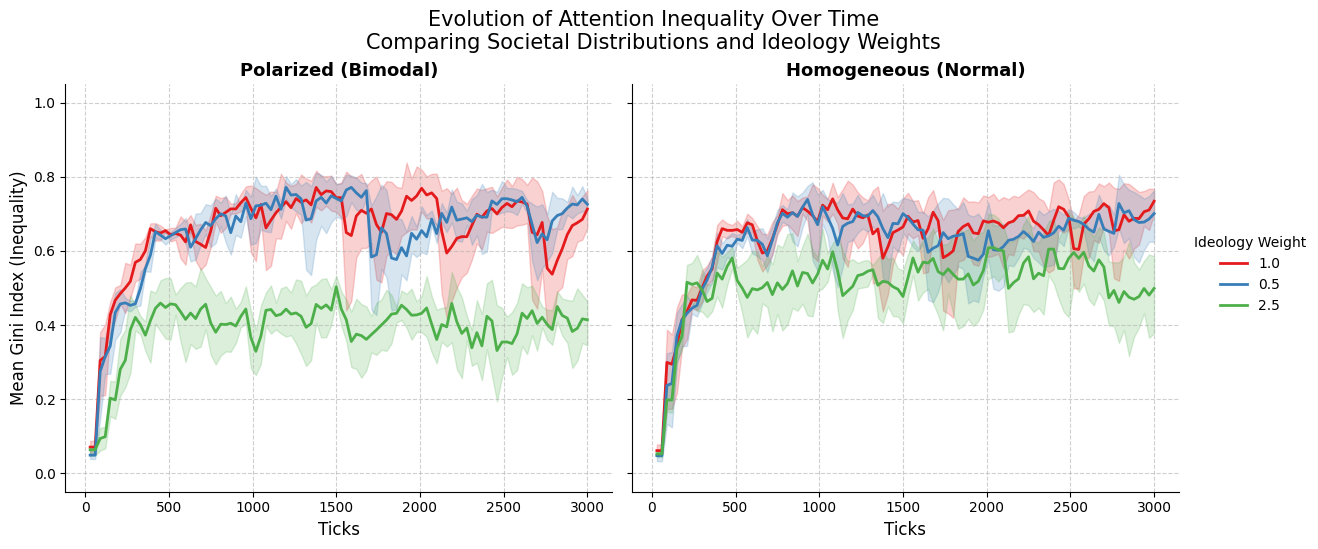

In [47]:
# Usage (Assuming df_all contains all 6 folders of data):
plot_comparative_gini_timeseries(df_all)